In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib
import os
import re
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import joblib
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
import itertools
warnings.filterwarnings('ignore')

In [25]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline

In [26]:
H = 90
THR = 1e-6
# ==============================
# OFFLINE TRAINING CONFIG

# Switch to TRAINING_MODE='expanding' if your device supports large memory usage for training expanding data
TRAINING_MODE = "rolling"     # "rolling" or "expanding"
ROLLING_WINDOW_SIZE = 20      # used only if TRAINING_MODE == "rolling"

ADD_FAMILY_AGG = True         # must match execution pipeline

## Phase 1

- Extract multi-day intraday returns files
- Introduce log-return ''target_reg'' as well as target class ''target_cls''.
- Cross-verify the target variables with the expected horizon bar returns

In [27]:
DATA_DIR = "train"  # adjust path if needed

def load_day_csv(day_id, data_dir=DATA_DIR):
    """
    Load one intraday file (one trading day), sort by ts_ns, and reset index.
    
    Parameters
    ----------
    day_id : int or str
        File identifier, e.g. 33 for '33.csv'.
    data_dir : str
        Directory where the CSV files live.
        
    Returns
    -------
    df : pd.DataFrame
        Sorted DataFrame with index 0..n-1 and original columns.
    """
    fname = f"{day_id}.csv"
    path = os.path.join(data_dir, fname)
    df = pd.read_csv(path)
    
    # Sort strictly by ts_ns; if ts_ns is missing, this will raise a KeyError (good early check)
    df = df.sort_values("ts_ns").reset_index(drop=True)
    return df



# def day_nan_report(df, required_cols=("ts_ns", "P3")):
#     rep = {}
#     for c in required_cols:
#         rep[f"missing_{c}"] = (c not in df.columns)
#         rep[f"nan_{c}"] = (df[c].isna().sum() if c in df.columns else None)
#     rep["n_rows"] = len(df)
#     rep["n_cols"] = df.shape[1]
#     rep["n_nan_total"] = int(df.isna().sum().sum())
#     rep["nan_rows"] = int(df.isna().any(axis=1).sum())
#     return rep

# def validate_day_or_raise(df, day_id, required_cols=("ts_ns", "P3"), max_nan_frac=0.0):
#     rep = day_nan_report(df, required_cols=required_cols)
#     if any(rep[f"missing_{c}"] for c in required_cols):
#         raise ValueError(f"Day {day_id}: missing required columns, report={rep}")
#     nan_frac = rep["n_nan_total"] / max(1, rep["n_rows"] * rep["n_cols"])
#     if nan_frac > max_nan_frac:
#         raise ValueError(f"Day {day_id}: too many NaNs (frac={nan_frac:.6f}), report={rep}")
#     return rep


# def filter_good_days(day_ids, data_dir=DATA_DIR, max_nan_frac=0.0, verbose=True):
#     good, bad = [], {}
#     for d in day_ids:
#         df = load_day_csv(d, data_dir=data_dir)
#         try:
#             rep = validate_day_or_raise(df, d, max_nan_frac=max_nan_frac)
#             good.append(d)
#         except Exception as e:
#             bad[d] = str(e)
#             if verbose:
#                 print(f"Skipping day {d}: {e}")
#     return good, bad


In [28]:
def add_forward_return_targets(
    df,
    price_col="P3",
    horizon=H,
    classification=True,
    threshold=THR
):
    """
    Add forward-looking targets on P3 with horizon >= 30 bars.
    
    Parameters
    ----------
    df : pd.DataFrame
        Single-day intraday data, already sorted by ts_ns and indexed 0..n-1.
    price_col : str
        Name of the tradable price column, here 'P3'.
    horizon : int
        Lookahead in bars. Must be >= 30.
    classification : bool
        If True, also create a sign-based classification target.
    threshold : float
        Dead-zone threshold on log-return for classification, e.g. 0.0 or 1e-4.
        
    Returns
    -------
    df_out : pd.DataFrame
        Copy of df with new columns:
          - 'target_reg': future log-return at horizon H
          - 'target_cls' (optional): sign-based label in {-1, 0, +1}
        Last `horizon` rows are dropped (no future price).
    """
    assert horizon >= 30, "Horizon must be at least 30 bars to satisfy spec."
    df = df.copy()
    
    # Ensure no zero or negative prices (should not happen, but be safe)
    if (df[price_col] <= 0).any():
        raise ValueError(f"Non-positive values found in {price_col}.")
    
    # Future price at t+H (shifted backward so that row t sees t+H)
    future_price = df[price_col].shift(-horizon)
    
    # Log-return from t to t+H
    target_reg = np.log(future_price) - np.log(df[price_col])
    df["target_reg"] = target_reg
    
    if classification:
        # Sign target with optional dead-zone
        # y > threshold -> +1, y < -threshold -> -1, else 0
        y = target_reg.values
        labels = np.zeros_like(y, dtype=int)
        labels[y > threshold] = 1
        labels[y < -threshold] = -1
        df["target_cls"] = labels
    
    # Drop rows where future price is NaN (last `horizon` rows)
    df_out = df.iloc[:-horizon].reset_index(drop=True)
    return df_out
    

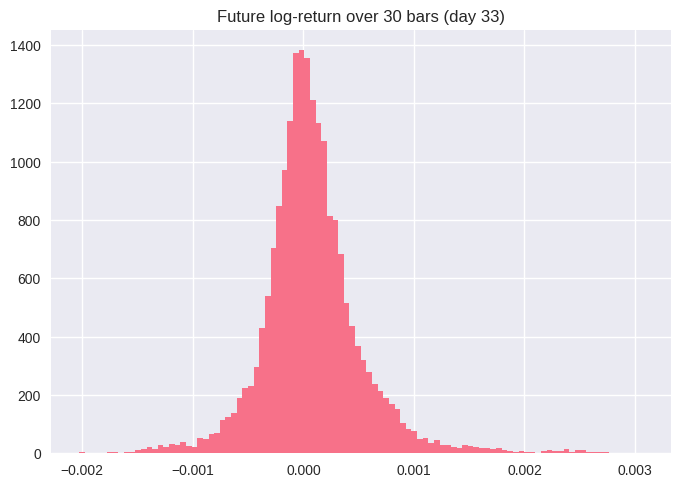

target_cls
 1    0.54875
-1    0.44880
 0    0.00245
Name: proportion, dtype: float64


In [29]:
df_33 = load_day_csv(20)


df_33_target = add_forward_return_targets(df_33, price_col="P3", horizon=H,
                                          classification=True, threshold=THR)


# Basic distribution of the regression target
df_33_target["target_reg"].hist(bins=100)
plt.title("Future log-return over 30 bars (day 33)")
plt.show()


df_33_target[["P3", "target_reg", "target_cls"]].head(), df_33_target.tail()
# Proportion of each class
print(df_33_target["target_cls"].value_counts(normalize=True))


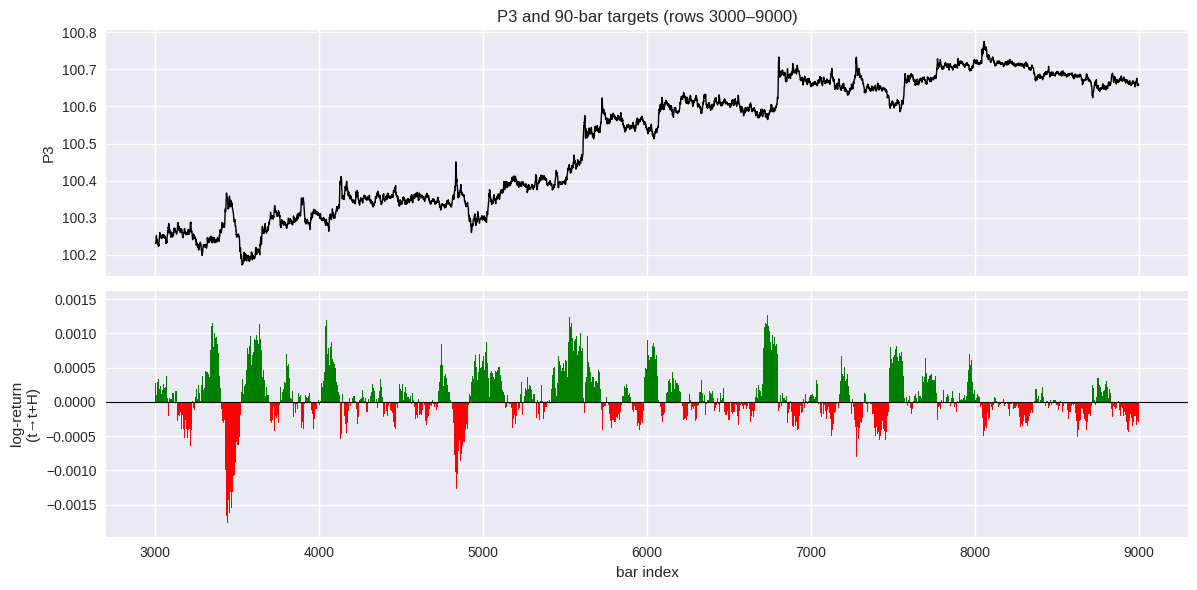

In [30]:
def plot_targets_for_day(
    df_with_targets,
    price_col="P3",
    horizon=H,
    start=3000,
    window=6000
):
    """
    Visual sanity check: show P3 and 30-bar-ahead log-returns with class labels.
    
    Parameters
    ----------
    df_with_targets : pd.DataFrame
        Output from add_forward_return_targets (last `horizon` rows dropped).
    price_col : str
        Tradable price column, 'P3'.
    horizon : int
        Lookahead used to build targets (for labeling only).
    start : int
        Starting index of the window to plot.
    window : int
        Number of rows to display.
    """
    end = min(start + window, len(df_with_targets))
    dfw = df_with_targets.iloc[start:end].copy()
    idx = dfw.index.to_numpy()
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # Top: P3 price path
    axes[0].plot(idx, dfw[price_col].values, color="black", linewidth=1)
    axes[0].set_ylabel(price_col)
    axes[0].set_title(f"{price_col} and {horizon}-bar targets (rows {start}–{end})")
    
    # Bottom: future log-return as bars, colored by class
    ret_vals = dfw["target_reg"].values
    cls_vals = dfw["target_cls"].values
    
    # Colors: -1 = red, 0 = grey, +1 = green
    colors = np.where(cls_vals > 0, "green", np.where(cls_vals < 0, "red", "grey"))
    axes[1].bar(idx, ret_vals, color=colors, width=1.0)
    axes[1].axhline(0.0, color="black", linewidth=0.8)
    axes[1].set_ylabel("log-return\n(t→t+H)")
    axes[1].set_xlabel("bar index")
    
    plt.tight_layout()
    plt.show()


plot_targets_for_day(df_33_target)

## Phase 2
- Feature sanitation class
- Build a clean feature matrix

In [31]:
def list_day_ids(data_dir=DATA_DIR, pattern=r"(\d+)\.csv"):
    """
    List integer day IDs available in the data_dir (e.g. 1 for '1.csv').
    """
    day_ids = []
    for fname in os.listdir(data_dir):
        m = re.match(pattern, fname)
        if m:
            day_ids.append(int(m.group(1)))
    return sorted(day_ids)

day_ids = list_day_ids()
print("Found days:", day_ids[:10], "... total:", len(day_ids))


Found days: [1, 2, 3, 4, 5, 6, 8, 9, 10, 11] ... total: 111


In [32]:
EXCLUDED_COLUMNS = ["ts_ns", "P3", "target_reg", "target_cls"] #
 # not used as raw features; P3 is our price/target base 

class FeatureSanitizer:
    """
    Simple feature sanitizer:
    - Drops explicitly excluded columns.
    - Drops constant columns (same value over the given data).
    
    The chosen feature list is stored and can be reapplied consistently
    to other days to avoid any leakage.
    """
    def __init__(self, excluded_cols=None):
        self.excluded_cols = set(excluded_cols) if excluded_cols is not None else set()
        self.feature_names_ = None
    
    def fit(self, df):
        # Start from all numeric columns
        cols = [c for c in df.columns if c not in self.excluded_cols]
        numeric_cols = df[cols].select_dtypes(include=["float64", "int64"]).columns.tolist()

        non_constant = []
        for c in numeric_cols:
            series = df[c]
            if series.nunique(dropna=False) <= 1:
                continue
            # Drop columns that are almost always zero
            zero_frac = (series == 0).mean()
            if zero_frac > 0.98:
                continue
            non_constant.append(c)

        self.feature_names_ = non_constant
        return self
    
    def transform(self, df):
        assert self.feature_names_ is not None, "Call fit() first."
        # Any missing columns (e.g. new day missing a feature) will raise KeyError,
        return df[self.feature_names_].copy()
    
    def fit_transform(self, df):
        return self.fit(df).transform(df)



# # # Sanity check
# df_33 = load_day_csv(20)
# sanitizer = FeatureSanitizer(excluded_cols=EXCLUDED_COLUMNS)
# X_33 = sanitizer.fit_transform(df_33)  # df_33_t already has targets
# print("Kept", X_33.shape[1], "features after dropping constants & exclusions.")


## Phase 3

- Define a baseline regressor model
- Define a day-wise training and validation set
- Single temporal split by day
- Train the baseline

In [36]:
class ReturnRegressor:
    """
    Thin wrapper around a regression model for future log-returns.
    Designed to be easily replaceable with more advanced models.
    """
    def __init__(self, base_model=None):
        if base_model is None:
            # CREATE THE MODEL INSTANCE and assign to self.model
            base_model = HistGradientBoostingRegressor(
            max_iter=500,           
            learning_rate=0.02,     
            max_depth=4,            
            min_samples_leaf=50,    
            l2_regularization=5.0,  
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,    
            max_bins=128            # Default, but explicit: handles price/volatility scales well
        )

        # else:    
        self.model = base_model
        
    
    # def __init__(self, base_model=None):
    #     if base_model is None:
    #         base_model = Ridge(alpha=1.0, random_state=42)
    #     self.model = base_model


    # def __init__(self, base_model=None):
    #     if base_model is None:

    #         base_model = ExtraTreesRegressor(
    #             n_estimators=100,
    #             max_depth=5,
    #             max_features='sqrt',
    #             min_samples_split=10,
    #             n_jobs=-1,             # Parallel processing
    #             random_state=42,
    #             verbose=0
    #         )
    #     self.model = base_model
    
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
    
    def predict(self, X):
        return self.model.predict(X)




## Phase 3: Continued

- Optionally, define classification metrics


In [37]:
def sign_from_return(r, threshold=THR):
    signs = np.zeros_like(r, dtype=int)
    signs[r > threshold] = 1
    signs[r < -threshold] = -1
    return signs

def directional_metrics(y_true_reg, y_pred_reg, threshold=THR, name=""):
    """
    Compute basic directional metrics from regression predictions.
    Treat 'up' vs 'not-up' and 'down' vs 'not-down' as two binary problems.
    """
    y_true_sign = sign_from_return(y_true_reg, threshold=threshold)
    y_pred_sign = sign_from_return(y_pred_reg, threshold=threshold)
    
    print(f"=== Directional metrics ({name}) ===")
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true_sign, y_pred_sign, labels=[-1, 0, 1]))
    print("\nClassification report:")
    print(classification_report(y_true_sign, y_pred_sign, labels=[-1, 0, 1]))
    
    # Optional: ROC-AUC for 'up' class vs rest
    up_true = (y_true_sign == 1).astype(int)
    up_score = y_pred_reg  # higher means more 'up'
    try:
        auc_up = roc_auc_score(up_true, up_score)
        print(f"ROC-AUC (up vs rest): {auc_up:.4f}")
    except ValueError:
        print("ROC-AUC (up vs rest): not defined (only one class present).")


In [35]:
def save_pipeline(model, sanitizer, path="model_pipeline.joblib"):
    """
    Save the fitted model + sanitizer to disk.
    """
    joblib.dump({"model": model, "sanitizer": sanitizer}, path)


def load_pipeline(path="model_pipeline.joblib"):
    """
    Load a previously saved model + sanitizer.
    """
    obj = joblib.load(path)
    return obj["model"], obj["sanitizer"]

# After reg_model.fit(...)
# save_pipeline(reg_model, sanitizer, path="models/model_pipeline_10days.joblib")


## Uncomment to extract a saved model
# reg_model_loaded, sanitizer_loaded = load_pipeline("models/model_pipeline_10days.joblib")


## Family Aggregate feature engineer

In [38]:
class FeatureEngineer:
    """
    Simple feature engineering using prefix-based families.
    
    Family = prefix before first '_', e.g.:
      'm0_T', 'm0_AI', ... -> family 'm0'
      'C_AU', 'C_BU', ...  -> family 'C'
      'F_H_B', 'F_H_S', .. -> family 'F'
    
    Parameters
    ----------
    add_family_agg : bool
        If True, add per-family aggregates (mean, std, min, max).
    keep_raw : bool
        If True, keep original raw features and add aggregates.
        If False, drop original features for families and keep only aggregates.
    excluded_cols : set or None
        Columns to exclude
    """
    def __init__(self, add_family_agg=True, keep_raw=True, excluded_cols=None):
        self.add_family_agg = add_family_agg
        self.keep_raw = keep_raw
        if excluded_cols is None:
            excluded_cols = ["ts_ns", "P3", "target_reg", "target_cls"] # {"ts_ns", "P1", "P2", "P3", "P4", "target_reg", "target_cls"}
        self.excluded_cols = excluded_cols
        self.family_groups_ = None
    
    def _get_prefix_family(self, col):
        if "_" in col:
            return col.split("_")[0]
        else:
            return col  # single token family (e.g. 'IC')
    
    def fit(self, X):
        if not self.add_family_agg:
            return self
        
        family_groups = {}
        for col in X.columns:
            if col in self.excluded_cols:
                continue
            fam = self._get_prefix_family(col)
            if fam not in family_groups:
                family_groups[fam] = []
            family_groups[fam].append(col)
        
        # Keep families with at least 2 members
        self.family_groups_ = {
            fam: cols for fam, cols in family_groups.items() if len(cols) >= 2
        }
        # print(f"FeatureEngineerSimple: Found {len(self.family_groups_)} families with 2+ members:")
        # for fam, cols in sorted(self.family_groups_.items()):
        #     print(f"  {fam}: {len(cols)} cols")
        return self
    
    def transform(self, X):
        if not self.add_family_agg or self.family_groups_ is None:
            return X.copy()
        
        X_out = X.copy()
        
        # Optionally drop raw features belonging to families
        if not self.keep_raw:
            cols_to_drop = []
            for fam, cols in self.family_groups_.items():
                cols_to_drop.extend(cols)
            cols_to_drop = [c for c in cols_to_drop if c in X_out.columns]
            X_out = X_out.drop(columns=cols_to_drop)
        
        # Add aggregates
        for fam, cols in self.family_groups_.items():
            fam_cols = [c for c in cols if c in X.columns]
            if len(fam_cols) == 0:
                continue
            X_out[f"{fam}_mean"] = X[fam_cols].mean(axis=1)
            # X_out[f"{fam}_range"] = X[fam_cols].max(axis=1) - X[fam_cols].min(axis=1)
            X_out[f"{fam}_std"] = X[fam_cols].std(axis=1)
            X_out[f"{fam}_min"] = X[fam_cols].min(axis=1)
            X_out[f"{fam}_max"] = X[fam_cols].max(axis=1)
        
        return X_out
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


## Phase 4: Walk forward per-day rolling / expanding window

- To feed into an expanding window loop, create a per-day temperory data
- Respecting causality, for each test day $D_t$, evaluate trainer on all days $<D_t$

In [39]:
def build_per_day_data(
    day_ids,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR,
    feature_engineer=None  # optional FeatureEngineer instance
):
    """
    For each day, build:
      - raw DataFrame with targets
      - feature DataFrame (without targets)
      - target Series (regression)
    
    Returns
    -------
    day_to_raw : dict[day_id -> pd.DataFrame]
        Each DataFrame includes target_reg and target_cls.
    day_to_features : dict[day_id -> pd.DataFrame]
        Features only (no targets), unsanitized.
    day_to_target_reg : dict[day_id -> pd.Series]
        Regression target per day.
    """
    day_to_raw = {}
    day_to_features = {}
    day_to_target_reg = {}
    
    for d in day_ids:
        df_day = load_day_csv(d, data_dir=data_dir)
        df_day_t = add_forward_return_targets(
            df_day,
            price_col="P3",
            horizon=horizon,
            classification=True,
            threshold=threshold
        )

        
        
        # Separate features / target
        y_reg = df_day_t["target_reg"].copy()
        feat_df = df_day_t.drop(columns=["target_reg", "target_cls"])

        # Apply feature engineering if provided
        if feature_engineer is not None:
            feat_df = feature_engineer.transform(feat_df)
        
        day_to_raw[d] = df_day_t
        day_to_features[d] = feat_df
        day_to_target_reg[d] = y_reg
    
    return day_to_raw, day_to_features, day_to_target_reg


## Phase 5: Trade execution engine

- Use fitted model, sanitizer, and a single day’s raw DataFrame to return a trade log
- Train model on previous days, run the execution on test day and collect PnL and evaluation metrics

In [40]:
def prediction_to_signal_persistent(
    pred,
    pred_std,
    prev_position,
    entry_z=1.0,
    exit_z=0.3
):
    """
    Convert regression prediction into a persistent trading signal.

    pred      : current regression prediction
    pred_std  : rolling std of past predictions (confidence proxy)
    prev_position : previous position (-1, 0, +1)
    """

    # Safety: no trading if std undefined
    if pred_std is None or pred_std <= 0 or np.isnan(pred_std):
        return 0

    z = pred / pred_std

    # Flat -> enter only if strong
    if prev_position == 0:
        if z > entry_z:
            return 1
        elif z < -entry_z:
            return -1
        else:
            return 0

    # Long position
    if prev_position == 1:
        if z < -entry_z:
            return -1   # strong flip
        elif z < exit_z:
            return 0    # exit
        else:
            return 1    # hold

    # Short position
    if prev_position == -1:
        if z > entry_z:
            return 1
        elif z > -exit_z:
            return 0
        else:
            return -1
    
    # Final fallback
    return 0

TC_RATE = 0.0001  # 0.01% transaction cost

def run_execution_for_day(
    df_day_raw,
    sanitizer,
    feature_engineer,  # can be None
    model,
    price_col="P3",
    threshold=THR,
    tc_rate=TC_RATE,
    # --- churn controls ---
    use_min_hold=True,
    min_hold_bars=30,
    use_flip_confirm=True,
    confirm_bars=2,
    force_flat_before_flip=True,
    use_horizon_decisions=True,
    decision_step=30,  
    ROLLING_PRED_WINDOW=200,
    entry_z=1.4,
    exit_z=0.3,
    use_risk_targeting=True,
    vol_window=200,
    target_risk=1.5,
    max_pos=1.5,
    min_vol=1e-12
):
    """
    Run an iterative, causal execution simulation for a single day.
    """

    df = df_day_raw.copy()
    df = df.sort_values("ts_ns").reset_index(drop=True)

    drop_cols = [c for c in ["target_reg", "target_cls"] if c in df.columns]
    feat_df = df.drop(columns=drop_cols)

    if feature_engineer is not None:
        feat_df = feature_engineer.transform(feat_df)

    X_day = sanitizer.transform(feat_df)

    prices = df[price_col].values
    rets = np.diff(prices, prepend=prices[0])
    vol = pd.Series(rets).rolling(vol_window, min_periods=vol_window).std().values

    n = len(df)

    # --- STATE ---
    direction = 0        
    position = 0.0       
    prev_price = prices[0]
    entry_price = None

    cum_pnl = 0.0
    cum_tc = 0.0
    realized_pnl = 0.0

    records = []

    bars_in_pos = 0
    pending_flip_dir = 0
    pending_flip_count = 0

    pred_history = []

    for t in range(n):
        price_t = prices[t]

        x_t = X_day.iloc[t:t+1]

        # --- SIGNAL GENERATION ---
        if use_horizon_decisions and (t % decision_step != 0):
            signal_t = direction   
        else:
            pred_t = model.predict(x_t)[0]
            pred_history.append(pred_t)

            if len(pred_history) >= 10:
                pred_std_t = np.std(pred_history[-ROLLING_PRED_WINDOW:])
            else:
                pred_std_t = None

            signal_t = prediction_to_signal_persistent(
                pred=pred_t,
                pred_std=pred_std_t,
                prev_position=direction,  # >>> FIX
                entry_z=entry_z,
                exit_z=exit_z
            )

        desired = signal_t

        # --- HOLDING TIME TRACKING ---
        if direction == 0:
            bars_in_pos = 0
        else:
            bars_in_pos += 1

        # --- MIN HOLD ---
        if use_min_hold and direction != 0 and bars_in_pos < min_hold_bars:
            desired = direction  

        # --- FLIP CONFIRMATION ---
        if use_flip_confirm and direction != 0:
            if desired == -direction:   # >>> FIX
                if pending_flip_dir != desired:
                    pending_flip_dir = desired
                    pending_flip_count = 1
                else:
                    pending_flip_count += 1

                if pending_flip_count < confirm_bars:
                    desired = direction
            else:
                pending_flip_dir = 0
                pending_flip_count = 0

        # --- FORCE FLAT BEFORE FLIP ---
        if force_flat_before_flip and direction != 0 and desired == -direction:
            desired = 0

        # >>> FIX: update direction BEFORE sizing
        direction = int(desired)
        assert direction in (-1, 0, 1)

        # --- POSITION SIZING ---
        if use_risk_targeting:
            vol_t = vol[t]
            if np.isnan(vol_t) or vol_t <= min_vol:
                new_position = 0.0
            else:
                scale = min(max_pos, target_risk / vol_t)
                new_position = direction * scale
        else:
            new_position = float(direction)

        # --- TRADE & COSTS ---
        trade = new_position - position
        traded_notional = abs(trade) * price_t
        tx_cost = traded_notional * tc_rate

        pnl_realized_t = 0.0
        if trade != 0 and position != 0:
            pnl_realized_t = (price_t - entry_price) * position
            realized_pnl += pnl_realized_t

        entry_price = price_t if new_position != 0 else None
        cum_tc += tx_cost

        mtm_pnl_t = (price_t - prev_price) * position
        cum_pnl += pnl_realized_t + mtm_pnl_t - tx_cost

        records.append({
            "ts_ns": df.loc[t, "ts_ns"],
            price_col: price_t,
            "entry_price": entry_price,
            # "pred": pred_t if 'pred_t' in locals() else np.nan,
            # "signal": signal_t,
            "position": new_position,
            "trade": trade,
            # "trade_price": price_t if trade != 0 else np.nan,
            "pnl_realized_t": pnl_realized_t,
            "pnl_mtm_t": mtm_pnl_t,
            "tx_cost_t": tx_cost,
            "cum_pnl": cum_pnl,
            "cum_realized_pnl": realized_pnl,
            "cum_tx_cost": cum_tc,
        })

        position = new_position
        prev_price = price_t

    trades_df = pd.DataFrame(records)
    trades_df["trade_count_cum"] = (trades_df["trade"] != 0).cumsum()

    return trades_df

In [41]:
def walk_forward_with_execution(
    day_ids,
    day_to_raw,
    day_to_features,
    day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,
    threshold=THR,
    tc_rate=TC_RATE,
    add_family_agg=True,  # on/off switch for family aggregates
    exec_params=None
):
    """
    Walk-forward evaluation with execution:
      - For each test day, train on all previous days.
      - Run execution engine on test day.
    
    Returns
    -------
    metrics_df : pd.DataFrame
        Per-day metrics including corr, acc_sign, and final cum_pnl.
    trades_by_day : dict
        day_id -> trades_df (per-day trade log).
    """
    if exec_params is None:
        exec_params = {}


    
    metrics = []
    trades_by_day = {}
    
    day_ids_sorted = sorted(day_ids)
    
    for i in range(min_train_days, len(day_ids_sorted)):
        test_day = day_ids_sorted[i]
        # train_days = day_ids_sorted[:i]
        ## Uncomment to undo rolling window testing
        window_size = 10
        train_days = day_ids_sorted[max(0, i - window_size):i]

        
        # Build training set
        X_train_list, y_train_list = [], []
        for d in train_days:
            X_train_list.append(day_to_features[d])
            y_train_list.append(day_to_target_reg[d])
        X_train = pd.concat(X_train_list, axis=0)
        y_train = pd.concat(y_train_list, axis=0)

        # Fit FeatureEngineer on training data (if enabled)
        if add_family_agg:
            feat_eng = FeatureEngineer(add_family_agg=True, keep_raw=True)
            X_train = feat_eng.fit_transform(X_train)
        else:
            feat_eng = None
        
        # Fit sanitizer on training features only
        sanitizer = FeatureSanitizer(excluded_cols=excluded_cols)
        X_train_sanitized = sanitizer.fit_transform(X_train)
        
        # Test day: apply same feature engineering + sanitization
        df_raw_test = day_to_raw[test_day]
        feat_test = day_to_features[test_day].copy()
        y_test = day_to_target_reg[test_day]
        if feat_eng is not None:
            feat_test = feat_eng.transform(feat_test)
        X_test_sanitized = sanitizer.transform(feat_test)
        

    # Fix the model initialization
        if base_model is None:
            # Create ReturnRegressor instance (which creates HistGradientBoostingRegressor inside)
            model = ReturnRegressor()
        else:
            # If base_model is already an instantiated model, use it directly
            # or wrap it in ReturnRegressor for consistency
            if isinstance(base_model, ReturnRegressor):
                model = base_model
            else:
                model = ReturnRegressor(base_model=base_model)
        
        model.fit(X_train_sanitized, y_train)
        
        # Regression & directional metrics for test day
        y_pred_test = model.predict(X_test_sanitized)
        mse = mean_squared_error(y_test, y_pred_test)
        try:
            r2 = r2_score(y_test, y_pred_test)
        except ValueError:
            r2 = np.nan
        corr = np.corrcoef(y_test, y_pred_test)[0, 1]
        
        y_true_sign = sign_from_return(y_test.values, threshold=threshold)
        y_pred_sign = sign_from_return(y_pred_test, threshold=threshold)
        acc = (y_true_sign == y_pred_sign).mean()

        # Execution engine
        trades_df = run_execution_for_day(
            df_day_raw=df_raw_test,
            sanitizer=sanitizer,
            feature_engineer=feat_eng,
            model=model,
            price_col="P3",
            threshold=threshold,
            tc_rate=tc_rate,
            use_min_hold=True, use_flip_confirm=True, force_flat_before_flip=True,
            **exec_params
        )
        

        
        final_cum_pnl = trades_df["cum_pnl"].iloc[-1]
        n_trades = (trades_df["trade"] != 0).sum()
        
        metrics.append({
            "test_day": test_day,
            "n_train_days": len(train_days),
            "mse": mse,
            "r2": r2,
            "corr": corr,
            "acc_sign": acc,
            "final_cum_pnl": final_cum_pnl,
            "n_trades": n_trades
        })
        
        trades_by_day[test_day] = trades_df
        
        print(f"Day {test_day}: corr={corr:.3f}, acc={acc:.3f}, PnL={final_cum_pnl:.4f}")
    
    metrics_df = pd.DataFrame(metrics)
    return metrics_df, trades_by_day


In [42]:
# day_ids_used = [day_ids[i] for i in range(0,40) if i != 29]
# day_ids = list_day_ids()
# day_ids_used, bad_days = filter_good_days(day_ids, max_nan_frac=0.0, verbose=True)
# # print("Bad days:", bad_days)


BAD_DAYS = {33}

day_ids = list_day_ids()
day_ids_used = [d for d in day_ids[:30] if d not in BAD_DAYS]


day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
    day_ids_used,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR,
    feature_engineer=None#FeatureEngineer() #None  # No aggregates
)

# # Run walk-forward WITHOUT family aggregates
# metrics_df, trades_by_day = walk_forward_with_execution(
#     day_ids=day_ids_used,
#     day_to_raw=day_to_raw,
#     day_to_features=day_to_features,
#     day_to_target_reg=day_to_target_reg,
#     excluded_cols=EXCLUDED_COLUMNS,
#     min_train_days=5,
#     base_model=None,   # use current ReturnRegressor default
#     threshold=THR,
#     tc_rate=TC_RATE,
#     add_family_agg=False  # OFF
# )

# metrics_df.tail()


# # # 1) Baseline (use_min_hold=False, use_flip_confirm=False, force_flat_before_flip=False)
metrics_base, trades_by_day_base = walk_forward_with_execution(
    day_ids=day_ids_used,
    day_to_raw=day_to_raw,
    day_to_features=day_to_features,
    day_to_target_reg=day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,
    threshold=THR,
    tc_rate=TC_RATE,
    add_family_agg=True
)

# # 2) Hold only (use_min_hold=True, min_hold_bars=30, others off)
# metrics_agg_only, trades_by_day_agg_only = walk_forward_with_execution(
#     day_ids=day_ids_used,
#     day_to_raw=day_to_raw,
#     day_to_features=day_to_features,
#     day_to_target_reg=day_to_target_reg,
#     excluded_cols=EXCLUDED_COLUMNS,
#     min_train_days=5,
#     base_model=None,
#     threshold=THR,
#     tc_rate=TC_RATE,
#     add_family_agg=True  
# )

# # # 3) Hold + flip confirm: min_hold_bars=30, confirm_bars=2, force_flat_before_flip=True
# metrics_agg_join, trades_by_day_agg_join = walk_forward_with_execution(
#     day_ids=day_ids_used,
#     day_to_raw=day_to_raw,
#     day_to_features=day_to_features,
#     day_to_target_reg=day_to_target_reg,
#     excluded_cols=EXCLUDED_COLUMNS,
#     min_train_days=5,
#     base_model=None,
#     threshold=THR,
#     tc_rate=TC_RATE,
#     add_family_agg=True  
# )






Day 6: corr=0.042, acc=0.531, PnL=0.0717
Day 8: corr=0.022, acc=0.510, PnL=0.0816
Day 9: corr=-0.085, acc=0.515, PnL=-0.5441
Day 10: corr=0.103, acc=0.528, PnL=1.0370
Day 11: corr=0.109, acc=0.523, PnL=0.0354
Day 12: corr=0.033, acc=0.555, PnL=0.9917
Day 13: corr=-0.005, acc=0.474, PnL=-1.2243
Day 14: corr=0.215, acc=0.531, PnL=1.5603
Day 15: corr=0.088, acc=0.536, PnL=1.3019
Day 16: corr=0.129, acc=0.543, PnL=0.6936
Day 18: corr=-0.047, acc=0.439, PnL=-0.8043
Day 19: corr=0.038, acc=0.522, PnL=0.6781
Day 20: corr=0.033, acc=0.379, PnL=-1.1723
Day 21: corr=-0.013, acc=0.526, PnL=0.8756
Day 22: corr=0.126, acc=0.477, PnL=-0.7000
Day 23: corr=0.022, acc=0.505, PnL=0.1488
Day 24: corr=0.039, acc=0.528, PnL=-0.1186
Day 26: corr=-0.073, acc=0.484, PnL=-0.3442
Day 27: corr=-0.021, acc=0.473, PnL=-0.0568
Day 28: corr=0.077, acc=0.500, PnL=-1.5423
Day 29: corr=0.032, acc=0.491, PnL=0.0611
Day 30: corr=-0.179, acc=0.494, PnL=0.6138
Day 31: corr=-0.004, acc=0.476, PnL=-1.3194
Day 32: corr=0.095,

In [43]:
# Compute stats
def summarize(metrics, name):
    pnl = metrics["final_cum_pnl"]
    print(f"\n=== {name} ===")
    print(f"Mean PnL/day: {pnl.mean():.4f}")
    print(f"Median PnL/day: {pnl.median():.4f}")
    print(f"Std PnL/day: {pnl.std():.4f}")
    print(f"Hit rate: {(pnl > 0).mean():.3f}")
    print(f"Sharpe: {pnl.mean() / (pnl.std() + 1e-12):.3f}")
    print(f"Avg trades/day: {metrics['n_trades'].mean():.1f}")
    print(f"Total trades: {metrics['n_trades'].sum():.1f}")

summarize(metrics_base, "Baseline (use_min_hold=False, use_flip_confirm=False, force_flat_before_flip=False)")
# summarize(metrics_agg_only, "Hold only (use_min_hold=True, min_hold_bars=30, others off)")
# summarize(metrics_agg_join, "Hold + flip confirm + Align execution with horizon")


=== Baseline (use_min_hold=False, use_flip_confirm=False, force_flat_before_flip=False) ===
Mean PnL/day: -0.0246
Median PnL/day: 0.0482
Std PnL/day: 0.8772
Hit rate: 0.542
Sharpe: -0.028
Avg trades/day: 6.6
Total trades: 159.0


## Design Offline training

In [ ]:
def train_offline_pipeline(
    day_ids,
    day_to_features,
    day_to_target_reg,
    excluded_cols,
    training_mode="rolling",
    rolling_window_size=None,
    add_family_agg=True,
    base_model=None
):
    """
    Train model + preprocessing OFFLINE using only past days.

    Parameters
    ----------
    day_ids : list
        Sorted list of available day_ids (already curated).
    training_mode : str
        "expanding" or "rolling".
    rolling_window_size : int or None
        Used only if training_mode == "rolling".
    """

    # Select training days

    if training_mode == "expanding":
        train_days = list(day_ids)

    elif training_mode == "rolling":
        if rolling_window_size is None:
            raise ValueError("rolling_window_size must be set for rolling mode")
        train_days = list(day_ids[-rolling_window_size:])

    else:
        raise ValueError(f"Unknown training_mode: {training_mode}")

    if len(train_days) == 0:
        raise ValueError("No training days selected")


    # Build training matrices

    X_list, y_list = [], []

    for d in train_days:
        X_list.append(day_to_features[d])
        y_list.append(day_to_target_reg[d])

    X_train = pd.concat(X_list, axis=0)
    y_train = pd.concat(y_list, axis=0)

    # Feature engineering

    if add_family_agg:
        feature_engineer = FeatureEngineer(add_family_agg=True, keep_raw=True)
        X_train = feature_engineer.fit_transform(X_train)
    else:
        feature_engineer = None

    # Feature sanitization

    sanitizer = FeatureSanitizer(excluded_cols=excluded_cols)
    X_train_sanitized = sanitizer.fit_transform(X_train)

    # Model training
    
    if base_model is None:
        model = ReturnRegressor()
    else:
        model = ReturnRegressor(base_model=base_model)

    model.fit(X_train_sanitized, y_train)

    return model, sanitizer, feature_engineer


def train_offline_from_config(
    day_ids,
    day_to_features,
    day_to_target_reg,
    excluded_cols
):
    return train_offline_pipeline(
        day_ids=day_ids,
        day_to_features=day_to_features,
        day_to_target_reg=day_to_target_reg,
        excluded_cols=excluded_cols,
        training_mode=TRAINING_MODE,
        rolling_window_size=ROLLING_WINDOW_SIZE,
        add_family_agg=ADD_FAMILY_AGG,
        base_model=None
    )


# OFFLINE TRAINING

BAD_DAYS = {33}

day_ids = list_day_ids()
day_ids_used = [d for d in day_ids[:40] if d not in BAD_DAYS]
day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
    day_ids_used,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR,
    feature_engineer=None#FeatureEngineer() #None  # No aggregates
)

model, sanitizer, feature_engineer = train_offline_from_config(
    day_ids=day_ids_used,
    day_to_features=day_to_features,
    day_to_target_reg=day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
)

# SINGLE-DAY EXECUTION TEST

test_day = day_ids_used[:20]
overall_pnl = 0
for day in test_day:
    trades_df = run_execution_for_day(
        df_day_raw=day_to_raw[day],#day_to_raw[test_day],
        sanitizer=sanitizer,
        feature_engineer=feature_engineer,
        model=model,
        price_col="P3",
        threshold=THR,
        tc_rate=TC_RATE,
        use_min_hold=True,
        use_flip_confirm=True,
        force_flat_before_flip=True
    )
    
    print("Final PnL:", trades_df["cum_pnl"].iloc[-1], "for day",day)
    overall_pnl += trades_df["cum_pnl"].iloc[-1]
print(overall_pnl/len(test_day)))

def save_trained_pipeline(model, sanitizer, feature_engineer, path):
    joblib.dump(
        {
            "model": model,
            "sanitizer": sanitizer,
            "feature_engineer": feature_engineer,
        },
        path
    )

def load_trained_pipeline(path):
    obj = joblib.load(path)
    return obj["model"], obj["sanitizer"], obj["feature_engineer"]

# Ignore or Research Purpose Code Not for Production pipeline

In [16]:
# Compute stats
def summarize(metrics, name):
    pnl = metrics["final_cum_pnl"]
    print(f"\n=== {name} ===")
    print(f"Mean PnL/day: {pnl.mean():.4f}")
    print(f"Median PnL/day: {pnl.median():.4f}")
    print(f"Std PnL/day: {pnl.std():.4f}")
    print(f"Hit rate: {(pnl > 0).mean():.3f}")
    print(f"Sharpe: {pnl.mean() / (pnl.std() + 1e-12):.3f}")
    print(f"Avg trades/day: {metrics['n_trades'].mean():.1f}")
    print(f"Total trades: {metrics['n_trades'].sum():.1f}")

summarize(metrics_base, "Baseline (use_min_hold=False, use_flip_confirm=False, force_flat_before_flip=False)")
# summarize(metrics_agg_only, "Hold only (use_min_hold=True, min_hold_bars=30, others off)")
# summarize(metrics_agg_join, "Hold + flip confirm + Align execution with horizon")


=== Baseline (use_min_hold=False, use_flip_confirm=False, force_flat_before_flip=False) ===
Mean PnL/day: 0.3563
Median PnL/day: 0.2896
Std PnL/day: 1.0172
Hit rate: 0.676
Sharpe: 0.350
Avg trades/day: 8.4
Total trades: 284.0


In [ ]:
# BAD_DAYS = {33}

# day_ids = list_day_ids()
# day_ids_used = [d for d in day_ids if d not in BAD_DAYS]

# day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
#     day_ids_used,
#     horizon=H,
#     threshold=THR,
#     data_dir=DATA_DIR
# )


# results_df = evaluate_walk_forward(
#     day_ids=day_ids_used,
#     day_to_features=day_to_features,
#     day_to_target_reg=day_to_target_reg,
#     excluded_cols=EXCLUDED_COLUMNS,
#     min_train_days=5,   # start testing from 6th day
#     base_model=None,    # uses your current ReturnRegressor default
#     threshold=THR
# )

# results_df.tail()


In [ ]:
def plot_walk_forward_results(results_df):
    """
    Plot correlation and sign accuracy over test days.
    """
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    days = results_df["test_day"].values
    corr = results_df["corr"].values
    acc = results_df["acc_sign"].values
    
    ax1.plot(days, corr, marker="o", color="tab:blue", label="Corr (y, y_hat)")
    ax1.set_xlabel("Test day ID")
    ax1.set_ylabel("Correlation", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    
    ax2 = ax1.twinx()
    ax2.plot(days, acc, marker="s", color="tab:orange", label="Accuracy (sign)")
    ax2.set_ylabel("Sign accuracy", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
    
    fig.tight_layout()
    plt.title("Walk-forward performance by test day")
    plt.show()
    
    # Optional: histogram of correlations
    plt.figure(figsize=(6, 3))
    plt.hist(corr, bins=15, alpha=0.7)
    plt.xlabel("Correlation")
    plt.ylabel("Count")
    plt.title("Distribution of per-day correlations")
    plt.tight_layout()
    plt.show()

plot_walk_forward_results(results_df)


In [10]:
def build_multi_day_dataset(
    day_ids,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR
):
    all_X = []
    all_y_reg = []
    all_y_cls = []
    all_days = []
    
    sanitizer = None
    
    for i, d in enumerate(day_ids):
        df_day = load_day_csv(d, data_dir=data_dir)
        df_day_t = add_forward_return_targets(
            df_day,
            price_col="P3",
            horizon=horizon,
            classification=True,
            threshold=threshold
        )
        
        # Separate features from targets explicitly
        y_reg_day = df_day_t["target_reg"].copy()
        y_cls_day = df_day_t["target_cls"].copy()
        
        # Drop targets from the feature DataFrame before sanitizing
        feat_df = df_day_t.drop(columns=["target_reg", "target_cls"])
        
        if i == 0:
            sanitizer = FeatureSanitizer(excluded_cols=EXCLUDED_COLUMNS)
            X_day = sanitizer.fit_transform(feat_df)
        else:
            X_day = sanitizer.transform(feat_df)
        
        all_X.append(X_day)
        all_y_reg.append(y_reg_day)
        all_y_cls.append(y_cls_day)
        all_days.append(pd.Series(d, index=X_day.index))
    
    X = pd.concat(all_X, axis=0).reset_index(drop=True)
    y_reg = pd.concat(all_y_reg, axis=0).reset_index(drop=True)
    y_cls = pd.concat(all_y_cls, axis=0).reset_index(drop=True)
    day_index = pd.concat(all_days, axis=0).reset_index(drop=True)
    
    return X, y_reg, y_cls, day_index, sanitizer


## Plot Visuals

### Visuals for PnL

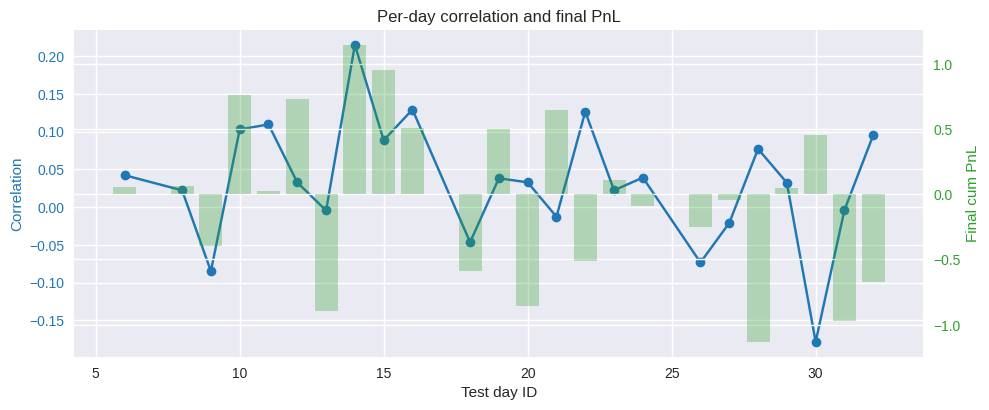

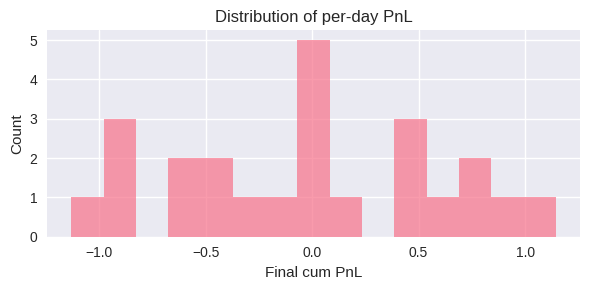

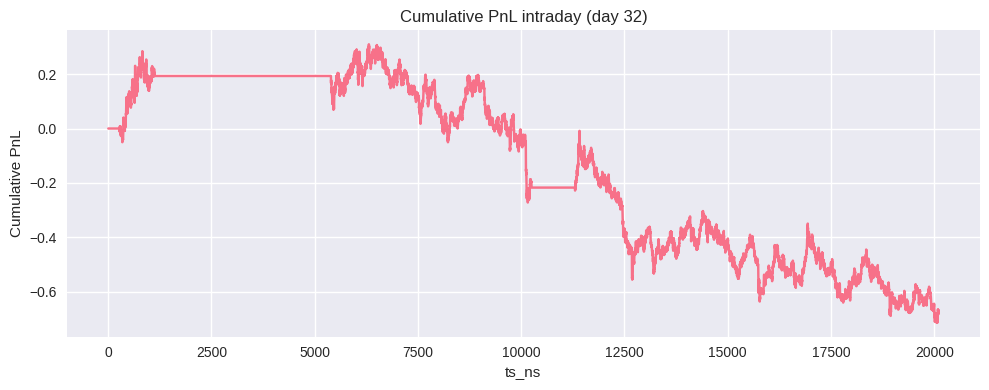

In [23]:
def plot_metrics_and_pnl(metrics_df):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    days = metrics_df["test_day"].values
    corr = metrics_df["corr"].values
    pnl = metrics_df["final_cum_pnl"].values
    
    ax1.plot(days, corr, marker="o", color="tab:blue", label="Corr")
    ax1.set_xlabel("Test day ID")
    ax1.set_ylabel("Correlation", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    
    ax2 = ax1.twinx()
    ax2.bar(days, pnl, alpha=0.3, color="tab:green", label="Final PnL")
    ax2.set_ylabel("Final cum PnL", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")
    
    fig.tight_layout()
    plt.title("Per-day correlation and final PnL")
    plt.show()
    
    # Histogram of per-day PnL
    plt.figure(figsize=(6, 3))
    plt.hist(pnl, bins=15, alpha=0.7)
    plt.xlabel("Final cum PnL")
    plt.ylabel("Count")
    plt.title("Distribution of per-day PnL")
    plt.tight_layout()
    plt.show()

plot_metrics_and_pnl(metrics_base)


example_day = metrics_base["test_day"].iloc[-1]  # last test day, for instance
trades_example = trades_by_day_base[example_day]

plt.figure(figsize=(10, 4))
plt.plot(trades_example["ts_ns"], trades_example["cum_pnl"])
plt.xlabel("ts_ns")
plt.ylabel("Cumulative PnL")
plt.title(f"Cumulative PnL intraday (day {example_day})")
plt.tight_layout()
plt.show()


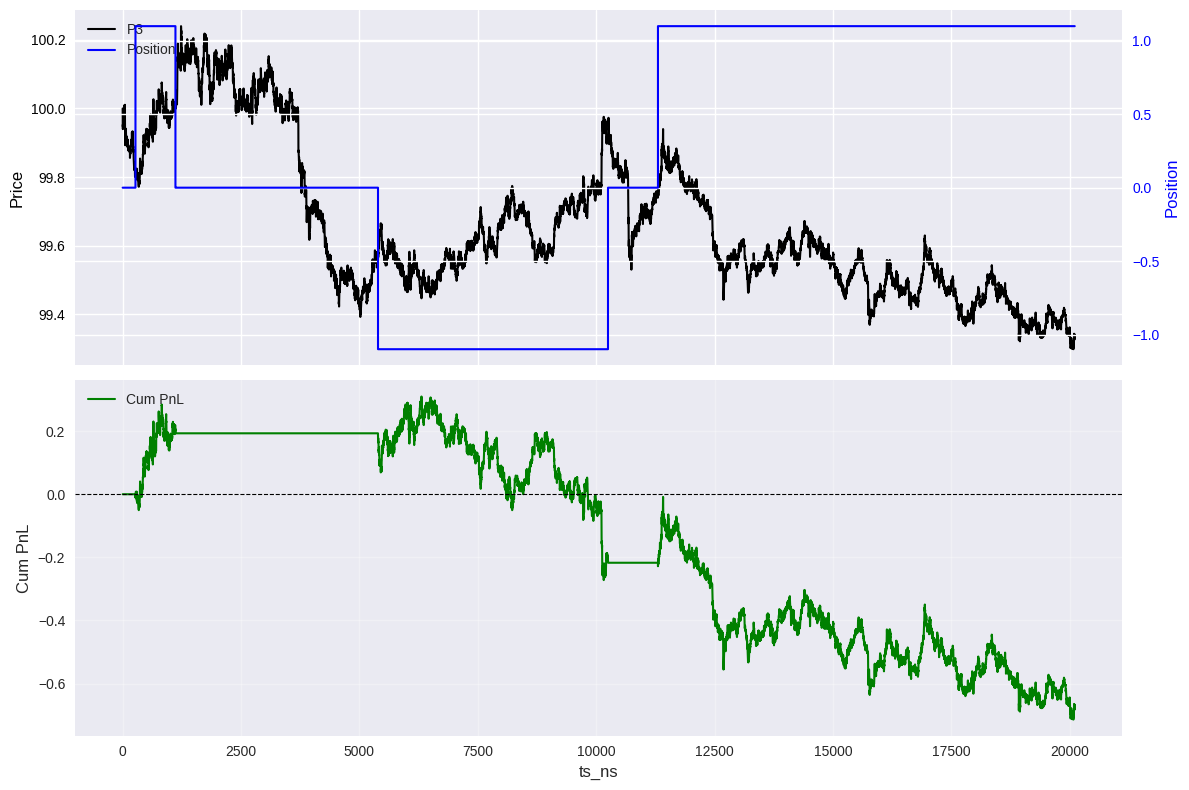

In [22]:
def plot_day_signals_and_pnl(trades_df, price_col="P3"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Create twin axes for the first subplot
    ax1 = axes[0]
    ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis
    
    # Plot price on left y-axis
    line1 = ax1.plot(trades_df["ts_ns"], trades_df[price_col], 
                     color="black", label="P3", linewidth=1.5)[0]
    ax1.set_ylabel("Price", color="black", fontsize=12)
    ax1.tick_params(axis='y', labelcolor="black")
    
    # Plot position on right y-axis
    line2 = ax2.step(trades_df["ts_ns"], trades_df["position"], where="post",
                     color="blue", label="Position", linewidth=1.5)[0]
    ax2.set_ylabel("Position", color="blue", fontsize=12)
    ax2.tick_params(axis='y', labelcolor="blue")
    
    # Combine legends
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    
    # Second plot (cumulative PnL) remains the same
    axes[1].plot(trades_df["ts_ns"], trades_df["cum_pnl"], 
                 color="green", label="Cum PnL", linewidth=1.5)
    axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("Cum PnL", fontsize=12)
    axes[1].set_xlabel("ts_ns", fontsize=12)
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

example_day = metrics_base["test_day"].iloc[-1]
plot_day_signals_and_pnl(trades_by_day_base[example_day])


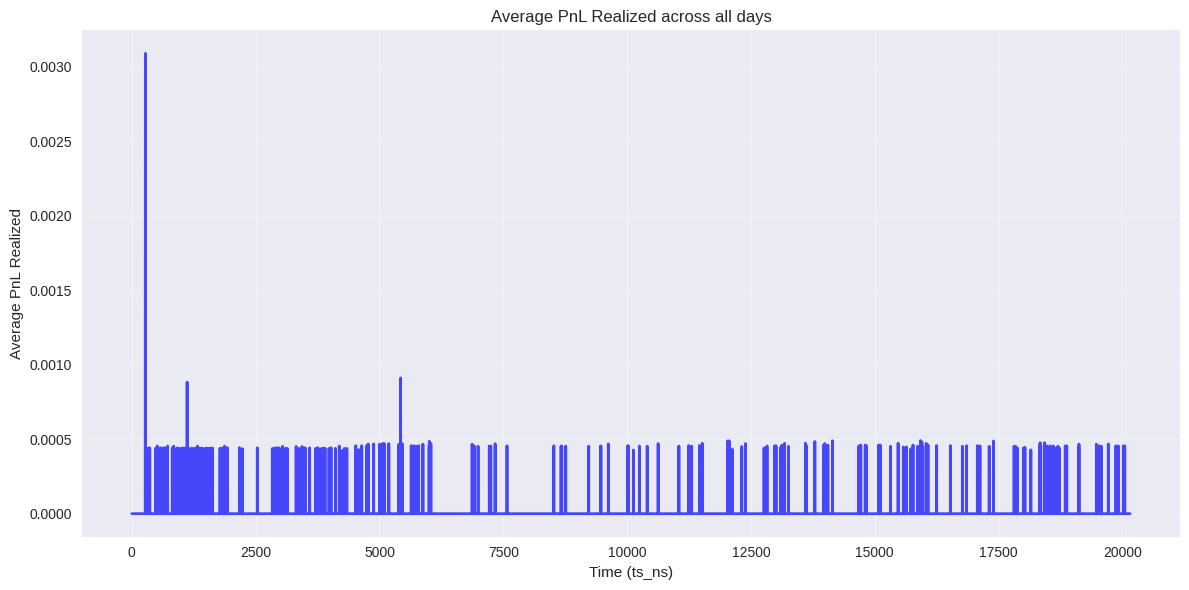

In [74]:
# 1. Combine all dataframes with a 'day' identifier
combined_data = []
for day, df in trades_by_day_base.items():
    df_copy = df[['ts_ns', 'tx_cost_t']].copy()
    df_copy['day'] = day  # Add day identifier
    combined_data.append(df_copy)

# Combine all data
combined_df = pd.concat(combined_data, ignore_index=True)

# 2. Group by ts_ns and calculate mean
avg_pnl = combined_df.groupby('ts_ns')['tx_cost_t'].mean().reset_index()
avg_pnl.columns = ['ts_ns', 'tx_cost_t']

# 3. Sort by time if needed
avg_pnl = avg_pnl.sort_values('ts_ns')

# 4. Plot
plt.figure(figsize=(12, 6))
plt.plot(avg_pnl['ts_ns'], avg_pnl['tx_cost_t'], 
         linewidth=2, color='blue', alpha=0.7)
plt.xlabel('Time (ts_ns)')
plt.ylabel('Average PnL Realized')
plt.title('Average PnL Realized across all days')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# tx_cost_t
# pnl_realized_t
# cum_pnl

In [43]:
trades_by_day_base[32]['pn'].value_counts()

position
1    13980
0     6020
Name: count, dtype: int64

## Master Function to loop over thresholds

- For a given set of train-test days, run the walk_forward_with_execution
- Evaluate performance & PnL metrics to find an optimal threshold
- Generate visuals

In [108]:
def summarize_pnl_from_metrics(metrics_df):
    pnl = metrics_df["final_cum_pnl"].values
    mean = float(np.mean(pnl))
    std = float(np.std(pnl, ddof=1)) if len(pnl) > 1 else float("nan")
    sharpe = mean / (std + 1e-12)
    hit = float(np.mean(pnl > 0))
    avg_trades = float(metrics_df["n_trades"].mean())
    return {"mean_pnl": mean, "std_pnl": std, "sharpe": sharpe, "hit": hit, "avg_trades": avg_trades}

def grid_search_exec_params(
    day_ids, day_to_raw, day_to_features, day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,
    threshold=THR,
    tc_rate=TC_RATE,
    add_family_agg=True,
    # constraints / objective
    max_avg_trades_per_day=15.0,
    objective="sharpe",
    # grid
    grid=None,
):
    if grid is None:
        grid = {
            "use_min_hold": [True],
            "min_hold_bars": [10, 30, 60],
            "use_flip_confirm": [True],
            "confirm_bars": [1, 2, 3],
            "force_flat_before_flip": [True],
            "use_horizon_decisions": [True],
            "decision_step": [10, 30, 90],
            "rolling_pred_window": [50, 100, 200],
            "entry_z": [0.8, 1.0, 1.2, 1.5],
            "exit_z": [0.1, 0.2, 0.3, 0.5],
        }

    keys = list(grid.keys())
    rows = []

    for values in itertools.product(*[grid[k] for k in keys]):
        exec_params = dict(zip(keys, values))

        metrics_df, _ = walk_forward_with_execution(
                        day_ids=day_ids_used,
                        day_to_raw=day_to_raw,
                        day_to_features=day_to_features,
                        day_to_target_reg=day_to_target_reg,
                        excluded_cols=EXCLUDED_COLUMNS,
                        min_train_days=5,
                        base_model=None,
                        threshold=THR,
                        tc_rate=TC_RATE,
                        add_family_agg=True,
                        exec_params=exec_params,
                    )    

    

        summary = summarize_pnl_from_metrics(metrics_df)
        summary_row = {**exec_params, **summary, "ntest_days": int(len(metrics_df))}
        rows.append(summary_row)

    results = pd.DataFrame(rows)

    # apply turnover constraint
    results_ok = results[results["avg_trades"] <= max_avg_trades_per_day].copy()
    if len(results_ok) == 0:
        # fall back if constraint too strict
        results_ok = results.copy()

    if objective == "sharpe":
        results_ok = results_ok.sort_values(["sharpe", "mean_pnl"], ascending=False)
    elif objective == "mean_pnl":
        results_ok = results_ok.sort_values(["mean_pnl", "sharpe"], ascending=False)
    else:
        raise ValueError("objective must be 'sharpe' or 'mean_pnl'")

    return results_ok.reset_index(drop=True)



day_ids_used = [day_ids[i] for i in range(30) if i != 29] #day_ids[:30]
day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
    day_ids_used,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR,
    feature_engineer=None  # No aggregates
)

small_grid = {
    "use_min_hold": [True, False],
    "min_hold_bars": [30, 60, 90],
    "use_flip_confirm": [True, False],
    "confirm_bars": [1, 2, 3],
    "force_flat_before_flip": [True, False],
    "use_horizon_decisions": [True, False],
    "decision_step": [30, 60, 90],
    "ROLLING_PRED_WINDOW": [100, 200],
    "entry_z": [1.2, 1.5, 1.7],
    "exit_z": [0.3, 0.5, 0.7],
    "use_risk_targeting"=[True, False],
    "vol_window"=[100, 200, 300],
    "target_risk"=[0.5, 1.0, 2.0],
    "max_pos"=[0.5, 1.0, 2.0],
    "min_vol"=[1e-12, 1e-10, 1e-8]
}

faster_grid = {
    "use_min_hold": [True],
    "min_hold_bars": [30, 60],
    "use_flip_confirm": [True],
    "confirm_bars": [2],
    "force_flat_before_flip": [True],
    "use_horizon_decisions": [True],
    "decision_step": [30, 45],

    "ROLLING_PRED_WINDOW": [200],
    "entry_z": [1.2, 1.3],
    "exit_z": [0.3],

    "use_risk_targeting": [True],
    "vol_window": [200, 400],
    "target_risk": [0.5, 1.0],
    "max_pos": [1.0],      # fixed
    "min_vol": [1e-10],
}


results = grid_search_exec_params(
    day_ids_used, day_to_raw, day_to_features, day_to_target_reg,
    base_model=None,  
    grid=faster_grid,
    max_avg_trades_per_day=15,
    objective="sharpe",
)
results.head(10)


Day 6: corr=0.114, acc=0.533, PnL=0.0419
Day 8: corr=0.129, acc=0.489, PnL=-0.1118
Day 9: corr=0.086, acc=0.515, PnL=-0.3947
Day 10: corr=0.046, acc=0.477, PnL=-0.7141
Day 11: corr=-0.012, acc=0.474, PnL=-0.6566
Day 12: corr=-0.062, acc=0.555, PnL=1.3279
Day 13: corr=0.091, acc=0.526, PnL=1.1188
Day 14: corr=0.205, acc=0.505, PnL=2.1520
Day 15: corr=-0.094, acc=0.546, PnL=1.6022
Day 16: corr=-0.041, acc=0.514, PnL=0.2157
Day 18: corr=-0.068, acc=0.594, PnL=0.7882
Day 19: corr=0.101, acc=0.526, PnL=1.1766
Day 20: corr=-0.048, acc=0.449, PnL=-3.5475
Day 21: corr=0.151, acc=0.522, PnL=0.9591
Day 22: corr=0.061, acc=0.477, PnL=-0.5834
Day 23: corr=0.022, acc=0.485, PnL=-0.1273
Day 24: corr=0.041, acc=0.498, PnL=-0.1639
Day 26: corr=0.119, acc=0.522, PnL=0.3170
Day 27: corr=0.049, acc=0.518, PnL=1.3135
Day 28: corr=0.022, acc=0.515, PnL=0.6383
Day 29: corr=0.001, acc=0.497, PnL=0.5795
Day 30: corr=0.161, acc=0.497, PnL=-0.8584
Day 31: corr=0.084, acc=0.461, PnL=-0.8815
Day 32: corr=0.094, a

,use_min_hold,min_hold_bars,use_flip_confirm,confirm_bars,force_flat_before_flip,use_horizon_decisions,decision_step,ROLLING_PRED_WINDOW,entry_z,exit_z,mean_pnl,std_pnl,sharpe,hit,avg_trades,ntest_days
0,True,30,True,2,True,True,30,200,1.2,0.3,0.307104,1.233328,0.249004,0.583333,5.125000,24
1,True,30,True,2,True,True,30,100,1.0,0.3,0.297179,1.267427,0.234474,0.583333,7.416667,24
2,True,30,True,2,True,True,30,200,1.0,0.3,0.272805,1.241917,0.219665,0.541667,6.333333,24
3,True,30,True,2,True,True,30,100,1.2,0.3,0.267356,1.233384,0.216766,0.583333,6.625000,24
4,True,30,True,2,True,True,30,100,1.0,0.2,0.259071,1.213003,0.213578,0.583333,6.958333,24
5,True,30,True,2,True,True,30,100,1.2,0.2,0.238767,1.193364,0.200079,0.583333,6.250000,24
6,True,30,True,2,True,True,30,200,1.2,0.2,0.206809,1.154825,0.179082,0.583333,4.583333,24
7,True,30,True,2,True,True,90,200,1.2,0.3,0.163645,0.974763,0.167882,0.583333,2.708333,24
8,True,30,True,2,True,True,90,200,1.0,0.3,0.161306,0.990875,0.162791,0.583333,3.083333,24
9,True,30,True,2,True,True,30,200,1.0,0.2,0.180831,1.154077,0.156689,0.541667,5.625000,24


In [70]:
import os
import csv
import itertools
import pandas as pd
import numpy as np


def summarize_pnl_from_metrics(metrics_df):
    pnl = metrics_df["final_cum_pnl"].values
    mean = float(np.mean(pnl))
    std = float(np.std(pnl, ddof=1)) if len(pnl) > 1 else float("nan")
    sharpe = mean / (std + 1e-12)
    hit = float(np.mean(pnl > 0))
    avg_trades = float(metrics_df["n_trades"].mean())
    return {
        "mean_pnl": mean,
        "std_pnl": std,
        "sharpe": sharpe,
        "hit": hit,
        "avg_trades": avg_trades,
    }


def grid_search_exec_params(
    day_ids,
    day_to_raw,
    day_to_features,
    day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,
    threshold=THR,
    tc_rate=TC_RATE,
    add_family_agg=False,
    # constraints / objective
    max_avg_trades_per_day=15.0,
    objective="sharpe",
    # grid
    grid=None,
    # checkpointing
    save_path="grid_search_files/grid_search_results.csv",
):
    if grid is None:
        raise ValueError("Grid must be provided")

    keys = list(grid.keys())

    # -------------------------------------------------------
    # Resume support: load existing results if present
    # -------------------------------------------------------
    if os.path.exists(save_path):
        done_df = pd.read_csv(save_path)
        done_configs = set(
            tuple(done_df[k].iloc[i] for k in keys)
            for i in range(len(done_df))
        )
        print(f"[Resume] Found {len(done_configs)} completed grid points")
        file_exists = True
    else:
        done_configs = set()
        file_exists = False

    # -------------------------------------------------------
    # Grid loop
    # -------------------------------------------------------
    total = np.prod([len(grid[k]) for k in keys])
    completed = len(done_configs)

    for i, values in enumerate(itertools.product(*[grid[k] for k in keys]), start=1):
        config_key = tuple(values)

        # Skip already completed configurations
        if config_key in done_configs:
            continue

        exec_params = dict(zip(keys, values))

        metrics_df, _ = walk_forward_with_execution(
            day_ids=day_ids,
            day_to_raw=day_to_raw,
            day_to_features=day_to_features,
            day_to_target_reg=day_to_target_reg,
            excluded_cols=excluded_cols,
            min_train_days=min_train_days,
            base_model=base_model,
            threshold=threshold,
            tc_rate=tc_rate,
            add_family_agg=add_family_agg,
            exec_params=exec_params,
        )

        summary = summarize_pnl_from_metrics(metrics_df)
        summary_row = {
            **exec_params,
            **summary,
            "ntest_days": int(len(metrics_df)),
        }

        # ---------------------------------------------------
        # Append checkpoint row to disk
        # ---------------------------------------------------
        write_header = not file_exists

        with open(save_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=summary_row.keys())
            if write_header:
                writer.writeheader()
                file_exists = True
            writer.writerow(summary_row)

        done_configs.add(config_key)
        completed += 1

        if completed % 5 == 0 or completed == total:
            print(f"[Checkpoint] {completed}/{total} grid points completed")

    # -------------------------------------------------------
    # Load full results from disk and post-process
    # -------------------------------------------------------
    results = pd.read_csv(save_path)

    # Apply turnover constraint
    results_ok = results[results["avg_trades"] <= max_avg_trades_per_day].copy()
    if len(results_ok) == 0:
        results_ok = results.copy()

    if objective == "sharpe":
        results_ok = results_ok.sort_values(
            ["sharpe", "mean_pnl"], ascending=False
        )
    elif objective == "mean_pnl":
        results_ok = results_ok.sort_values(
            ["mean_pnl", "sharpe"], ascending=False
        )
    else:
        raise ValueError("objective must be 'sharpe' or 'mean_pnl'")

    return results_ok.reset_index(drop=True)



faster_grid = {
    "use_min_hold": [True],
    "min_hold_bars": [30, 60],
    "use_flip_confirm": [True],
    "confirm_bars": [2],
    "force_flat_before_flip": [True],
    "use_horizon_decisions": [True],
    "decision_step": [30, 45],

    "ROLLING_PRED_WINDOW": [200],
    "entry_z": [1.2, 1.3],
    "exit_z": [0.3],

    "use_risk_targeting": [True],
    "vol_window": [200, 400],
    "target_risk": [0.5, 1.0],
    "max_pos": [1.0],      # fixed
    "min_vol": [1e-10],
}

day_ids_used = [day_ids[i] for i in range(30) if i != 29] #day_ids[:30]
day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
    day_ids_used,
    horizon=H,
    threshold=THR,
    data_dir=DATA_DIR,
    feature_engineer=None  # No aggregates
)


results = grid_search_exec_params(
    day_ids_used,
    day_to_raw,
    day_to_features,
    day_to_target_reg,
    base_model=None,
    grid=faster_grid,
    max_avg_trades_per_day=15,
    objective="sharpe",
    save_path="faster_grid_results.csv",
)

results.head(10)


# --- PARTIAL RESULTS INSPECTION ---
# df_partial = pd.read_csv("faster_grid_results.csv")
# df_partial.sort_values("sharpe", ascending=False).head(10)

# Example additional diagnostics:
# df_partial.groupby("decision_step")["sharpe"].mean().sort_values(ascending=False)
# df_partial.plot.scatter(x="avg_trades", y="sharpe")

Day 6: corr=0.155, acc=0.531, PnL=0.0478
Day 8: corr=0.090, acc=0.491, PnL=-0.1140
Day 9: corr=0.155, acc=0.515, PnL=-0.3627
Day 10: corr=0.160, acc=0.485, PnL=-0.3918
Day 11: corr=-0.009, acc=0.454, PnL=-1.2273
Day 12: corr=-0.062, acc=0.556, PnL=1.5390
Day 13: corr=0.049, acc=0.505, PnL=1.0392
Day 14: corr=0.144, acc=0.521, PnL=1.8826
Day 15: corr=-0.106, acc=0.548, PnL=0.5958
Day 16: corr=-0.034, acc=0.514, PnL=0.3250
Day 18: corr=-0.064, acc=0.542, PnL=0.3010
Day 19: corr=0.086, acc=0.533, PnL=1.3918
Day 20: corr=-0.043, acc=0.463, PnL=-2.7298
Day 21: corr=0.147, acc=0.536, PnL=1.2652
Day 22: corr=0.049, acc=0.477, PnL=-0.4652
Day 23: corr=0.011, acc=0.485, PnL=-0.0831
Day 24: corr=0.061, acc=0.498, PnL=-0.1968
Day 26: corr=0.091, acc=0.512, PnL=0.4092
Day 27: corr=0.057, acc=0.544, PnL=1.5057
Day 28: corr=0.038, acc=0.509, PnL=0.8132
Day 29: corr=-0.025, acc=0.491, PnL=0.7815
Day 30: corr=0.075, acc=0.494, PnL=-1.0697
Day 31: corr=0.096, acc=0.461, PnL=-0.8796
Day 32: corr=0.088, 

,use_min_hold,min_hold_bars,use_flip_confirm,confirm_bars,force_flat_before_flip,use_horizon_decisions,decision_step,ROLLING_PRED_WINDOW,entry_z,exit_z,use_risk_targeting,vol_window,target_risk,max_pos,min_vol,mean_pnl,std_pnl,sharpe,hit,avg_trades,ntest_days
0,True,30,True,2,True,True,30,200,1.2,0.3,True,200,0.5,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
1,True,30,True,2,True,True,30,200,1.2,0.3,True,200,1.0,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
2,True,30,True,2,True,True,30,200,1.2,0.3,True,400,0.5,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
3,True,30,True,2,True,True,30,200,1.2,0.3,True,400,1.0,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
4,True,60,True,2,True,True,30,200,1.2,0.3,True,200,0.5,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
5,True,60,True,2,True,True,30,200,1.2,0.3,True,200,1.0,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
6,True,60,True,2,True,True,30,200,1.2,0.3,True,400,0.5,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
7,True,60,True,2,True,True,30,200,1.2,0.3,True,400,1.0,1.0,1.000000e-10,0.201541,1.052195,0.191543,0.583333,6.208333,24
8,True,30,True,2,True,True,30,200,1.3,0.3,True,200,0.5,1.0,1.000000e-10,0.196156,1.026609,0.191072,0.583333,5.750000,24
9,True,30,True,2,True,True,30,200,1.3,0.3,True,200,1.0,1.0,1.000000e-10,0.196156,1.026609,0.191072,0.583333,5.750000,24


In [17]:
def evaluate_thresholds(
    thresholds,
    day_ids,
    day_to_raw,
    day_to_features,
    day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,
    horizon_label=None
):
    """
    Loop over thresholds, run walk_forward_with_execution for each,
    and compute summary statistics plus comparison plots.
    
    Parameters
    ----------
    thresholds : list[float]
        Thresholds for mapping predictions -> signals.
    day_ids : list[int]
        Day IDs to use (subset, sorted).
    day_to_raw, day_to_features, day_to_target_reg : dicts
        Output from build_per_day_data.
    excluded_cols : list[str]
        Columns to exclude in sanitizer.
    min_train_days : int
        Minimum number of days before starting evaluation.
    base_model : estimator or None
        If None, uses ReturnRegressor().model as current default.
    horizon_label : str or None
        Optional label (e.g. "H=90") to annotate plots.
    
    Returns
    -------
    summary_df : pd.DataFrame
        One row per threshold with summary stats.
    all_metrics : dict
        threshold -> per-day metrics_df.
    all_trades : dict
        threshold -> trades_by_day dict.
    """
    summaries = []
    all_metrics = {}
    all_trades = {}
    
    for thr in thresholds:
        print(f"\n=== Evaluating threshold = {thr} ===")
        metrics_df, trades_by_day = walk_forward_with_execution(
            day_ids=day_ids,
            day_to_raw=day_to_raw,
            day_to_features=day_to_features,
            day_to_target_reg=day_to_target_reg,
            excluded_cols=excluded_cols,
            min_train_days=min_train_days,
            base_model=base_model,
            threshold=thr,
            tc_rate=TC_RATE
        )
        
        pnl = metrics_df["final_cum_pnl"]
        n_trades rolling_pred_window= metrics_df["n_trades"]
        
        mean_pnl = pnl.mean()
        median_pnl = pnl.median()
        std_pnl = pnl.std(ddof=1)
        hit_rate = (pnl > 0).mean()
        sharpe = mean_pnl / (std_pnl + 1e-12)
        avg_trades = n_trades.mean()
        
        print(f"Mean PnL/day: {mean_pnl:.4f}, Median: {median_pnl:.4f}, "
              f"Std: {std_pnl:.4f}, Hit rate: {hit_rate:.3f}, Sharpe: {sharpe:.3f}, "
              f"Avg trades/day: {avg_trades:.1f}")
        
        summaries.append({
            "threshold": thr,
            "mean_pnl": mean_pnl,
            "median_pnl": median_pnl,
            "std_pnl": std_pnl,
            "hit_rate": hit_rate,
            "sharpe": sharpe,
            "avg_trades_per_day": avg_trades,
            "n_test_days": len(metrics_df)
        })
        
        all_metrics[thr] = metrics_df
        all_trades[thr] = trades_by_day
    
    summary_df = pd.DataFrame(summaries).sort_values("threshold").reset_index(drop=True)
    
    # Plot mean PnL and Sharpe vs threshold
    plt.figure(figsize=(8, 4))
    plt.plot(summary_df["threshold"], summary_df["mean_pnl"], marker="o", label="Mean PnL/day")
    plt.xlabel("Threshold")
    plt.ylabel("Mean PnL/day")
    title = "Mean PnL vs threshold"
    if horizon_label:
        title += f" ({horizon_label})"
    plt.title(title)
    plt.axhline(0.0, color="black", linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.plot(summary_df["threshold"], summary_df["sharpe"], marker="o", color="orange", label="Daily Sharpe")
    plt.xlabel("Threshold")
    plt.ylabel("Daily Sharpe")
    title = "Sharpe vs threshold"
    if horizon_label:
        title += f" ({horizon_label})"
    plt.title(title)
    plt.axhline(0.0, color="black", linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Optional: trades per day vs threshold
    plt.figure(figsize=(8, 4))
    plt.plot(summary_df["threshold"], summary_df["avg_trades_per_day"], marker="o", color="green",
             label="Avg trades/day")
    plt.xlabel("Threshold")
    plt.ylabel("Avg trades/day")
    title = "Trading intensity vs threshold"
    if horizon_label:
        title += f" ({horizon_label})"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return summary_df, all_metrics, all_trades


In [ ]:
# pnl = metrics_df["final_cum_pnl"]
# print("Mean PnL per day:", pnl.mean())
# print("Median PnL per day:", pnl.median())
# print("Std PnL per day:", pnl.std())
# print("Hit rate (P>0):", (pnl > 0).mean())

# daily_returns = pnl  # or pnl / notional if you define a capital base
# sharpe = daily_returns.mean() / (daily_returns.std() + 1e-12)
# print("Daily Sharpe (approx):", sharpe)


# H = 90
# THRESHOLDS = [1e-6, 5e-3, 1e-2]
THRESHOLDS = [1e-5]

# Rebuild per-day data if you changed H
day_ids_all = list_day_ids()
day_ids_used = [day_ids_all[i] for i in range(20) if i != 29] 
day_to_raw, day_to_features, day_to_target_reg = build_per_day_data(
    day_ids_used,
    horizon=H,
    threshold=THR,    # label threshold; can keep small
    data_dir=DATA_DIR
)

summary_df, all_metrics, all_trades = evaluate_thresholds(
    thresholds=THRESHOLDS,
    day_ids=day_ids_used,
    day_to_raw=day_to_raw,
    day_to_features=day_to_features,
    day_to_target_reg=day_to_target_reg,
    excluded_cols=EXCLUDED_COLUMNS,
    min_train_days=5,
    base_model=None,          # current default model (Ridge or small GBDT)
    horizon_label=f"H={H}"
)

summary_df
